# FAPE, ThresholdOptimizer Results Aggregation

Summary of the fairness intervention across all models and domains. The script aggregates ThresholdOptimizer results for logistic regression, random forest and gradient boosting across the seven domain scripts into one comparison table and eight figures. The seventh plots every pair's baseline DPD against its DPD after the constraint, and the eighth shows what the two sensitivity checks change. MEPS, the eighth evaluation, is held in `MEPS_RESULTS` and reported in Table 2. Models a domain did not evaluate are left blank in the figures rather than drawn as zero. It complements `cross_domain_comparison.py`, which covers gradient boosting only, by showing model-level variation within each domain, and asks whether gradient boosting consistently outperforms the other two models under the constraints.

Code: `src/threshold_aggregation.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from threshold_aggregation import run_threshold_aggregation

run_threshold_aggregation();  # returns RESULTS; the semicolon keeps Jupyter from echoing it

FAPE, ThresholdOptimizer Results Aggregation

--- Baseline Accuracy by Model and Domain ---
  COMPAS          LR=0.686 RF=0.637 GB=0.674
  Folktables      LR=0.740 RF=0.726 GB=0.756
  Law School      LR=N/A RF=N/A GB=N/A
  Lending Club    LR=N/A RF=N/A GB=N/A
  Agricultural    LR=N/A RF=N/A GB=N/A
  FairGround (Education/law_school_lequy) LR=0.913 RF=0.907 GB=0.910
  Student (math)  LR=0.646 RF=0.633 GB=0.658

--- Post-DP DPD by Model and Domain ---
  COMPAS          LR=0.714 RF=0.714 GB=0.571
  Folktables      LR=0.348 RF=0.193 GB=0.373
  Law School      LR=0.011 RF=N/A GB=0.030
  Lending Club    LR=0.019 RF=N/A GB=0.018
  Agricultural    LR=0.016 RF=N/A GB=0.031
  FairGround (Education/law_school_lequy) LR=0.010 RF=0.012 GB=0.014
  Student (math)  LR=0.010 RF=0.363 GB=0.215

--- Key Findings (computed from RESULTS, not hardcoded; see Decision 12) ---
  GB highest baseline accuracy in 3/5 true-accuracy domains: ['COMPAS', 'Folktables', 'FairGround (Education/law_school_lequy)', 'Stude

  Fig 1 saved, aggregation_baseline_accuracy.png (split accuracy/AUC panels)
  Fig 2 saved, aggregation_post_dp_dpd.png


  Fig 3 saved, aggregation_post_eo_eod.png
  Fig 4 saved, aggregation_dpd_heatmap.png
  Fig 5 saved, aggregation_eod_heatmap.png


  Fig 6 saved, aggregation_acc_cost_heatmap.png

--- Effectiveness pattern ---
  DPD improved in 9 of 14 pairs with baseline DPD above 0.2, worsened in 3 of 4 pairs below 0.05
  Worsened pairs that improve under a check: COMPAS LR (0.714 to 0.187), COMPAS RF (0.714 to 0.163), Folktables LR (0.348 to 0.114), Folktables GB (0.373 to 0.078), Student (math) RF (0.363 to 0.007), MEPS RF (0.253 to 0.037)


  Fig 7 saved, aggregation_effectiveness_pattern.png


  Fig 8 saved, aggregation_check_designs.png
  The constraint reverses direction under a check in 6 of 12 pairs

--- ThresholdOptimizer Aggregation complete ---
  8 figures saved to figures/stage2/
  See Key Findings above for computed baseline performance and DP improvement leaders
  Note: 3 domains (Law School, Lending Club, Agricultural) report AUC not accuracy,
        and lack RandomForest results entirely, see Decisions 13 and 16


## 1. Baseline accuracy and AUC by model

Baseline performance of each model, with domains that report accuracy and domains that report AUC in separate panels.

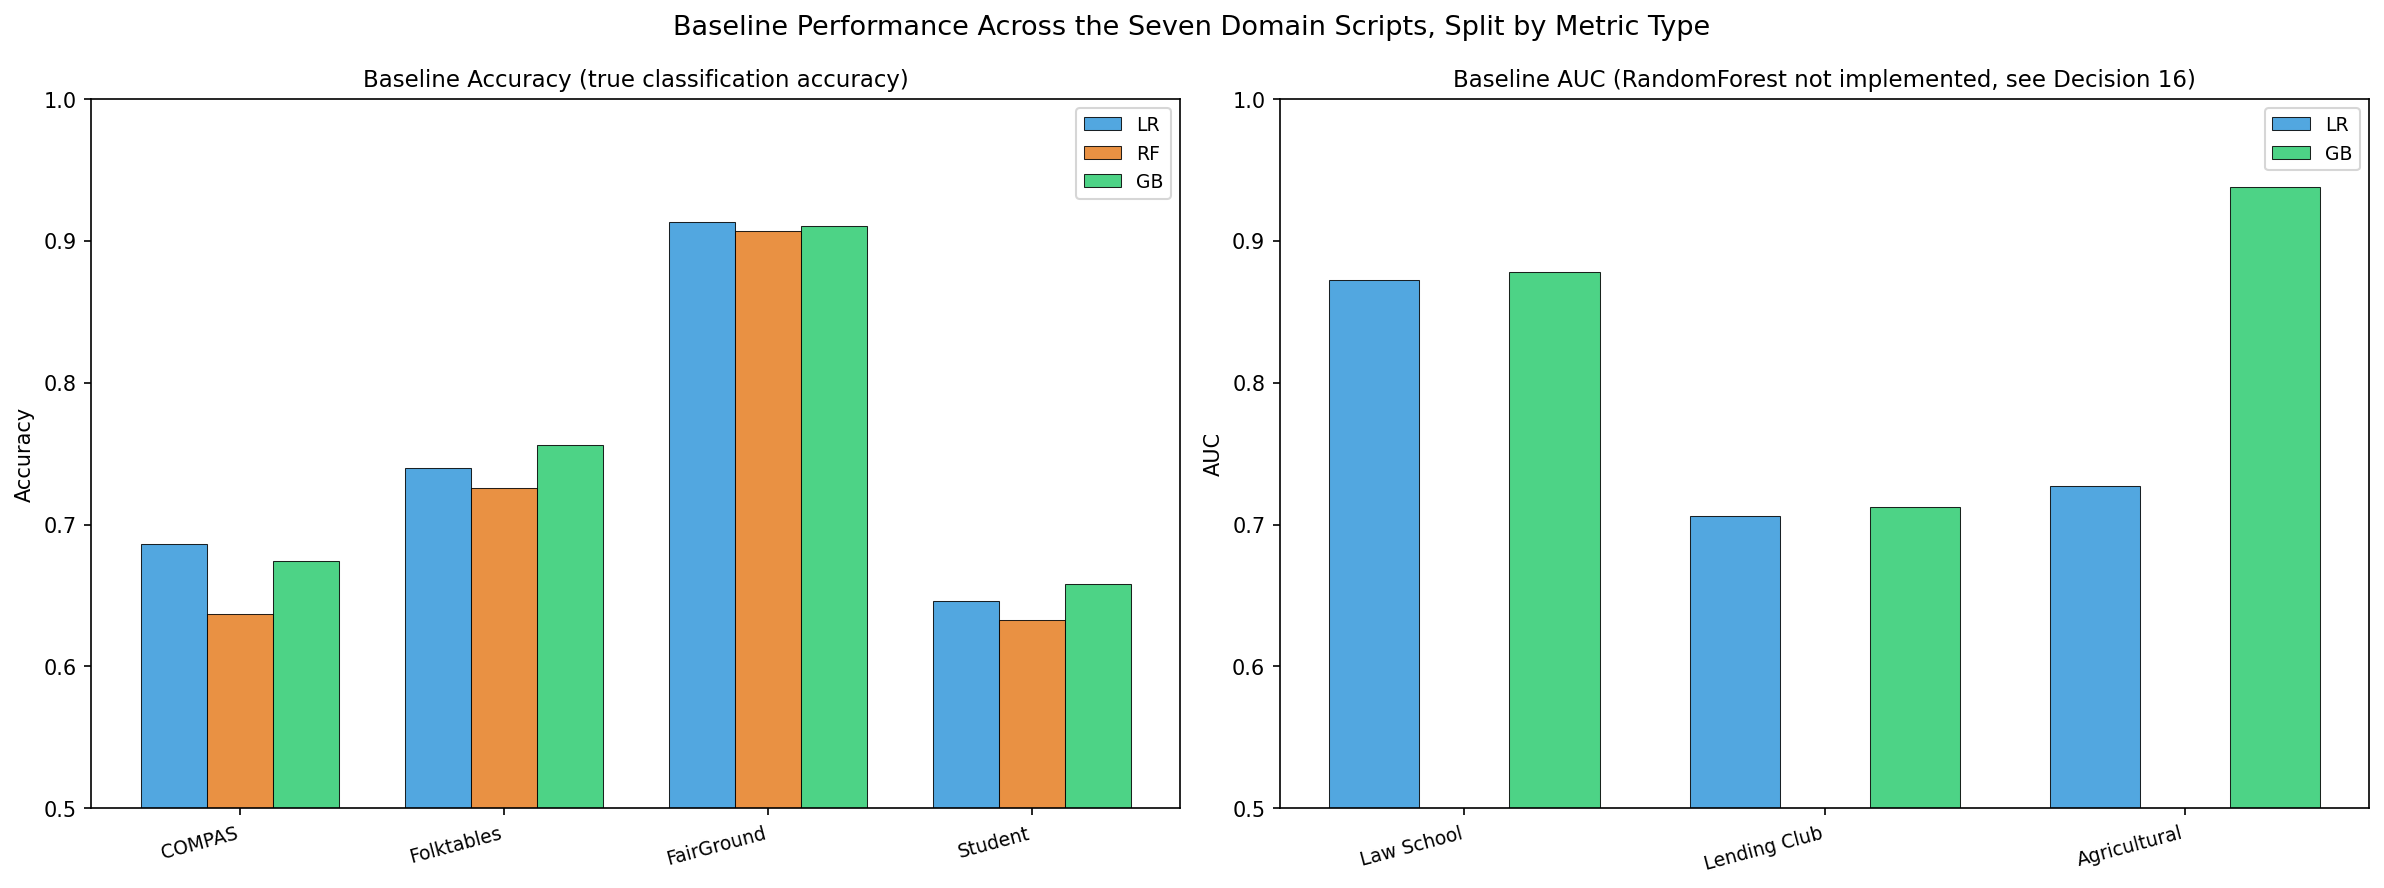

In [3]:
display(Image('figures/stage2/aggregation_baseline_accuracy.png'))

## 2. DPD after the demographic parity constraint

Demographic parity difference for each model after the demographic parity constraint, by domain.

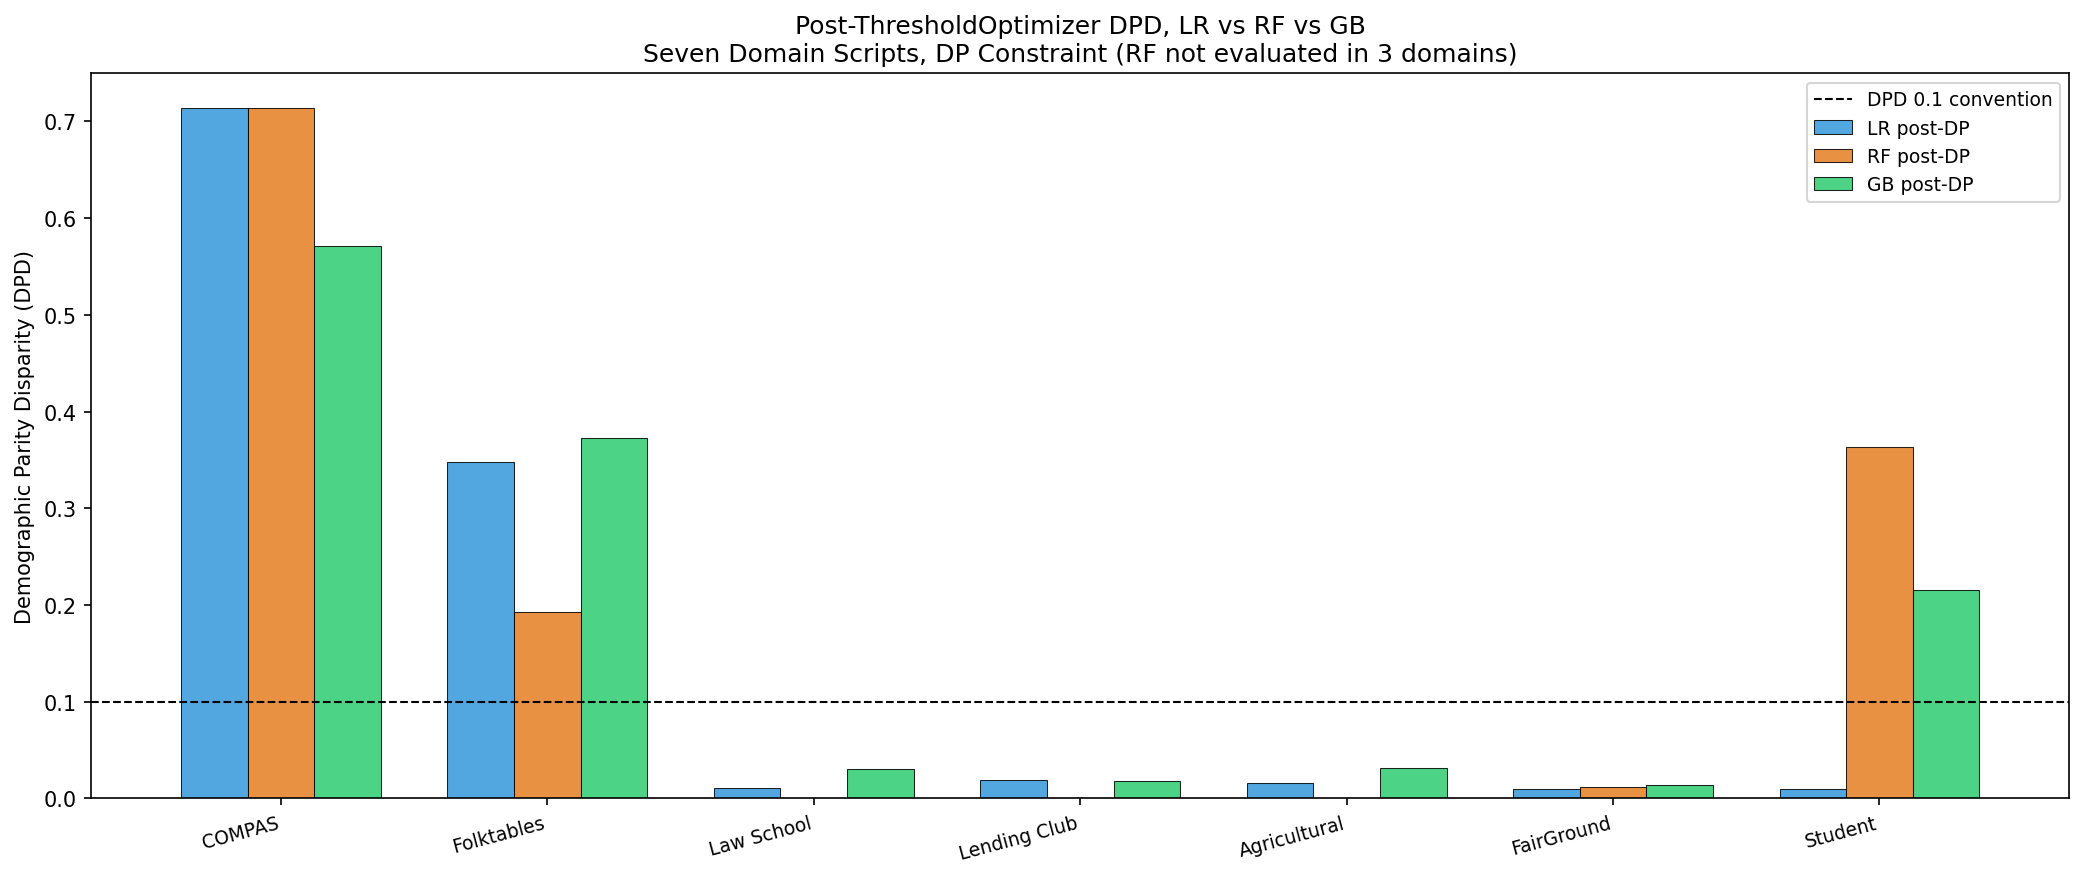

In [4]:
display(Image('figures/stage2/aggregation_post_dp_dpd.png'))

## 3. EOD after the equalized odds constraint

Equalized odds difference for each model after the equalized odds constraint, by domain.

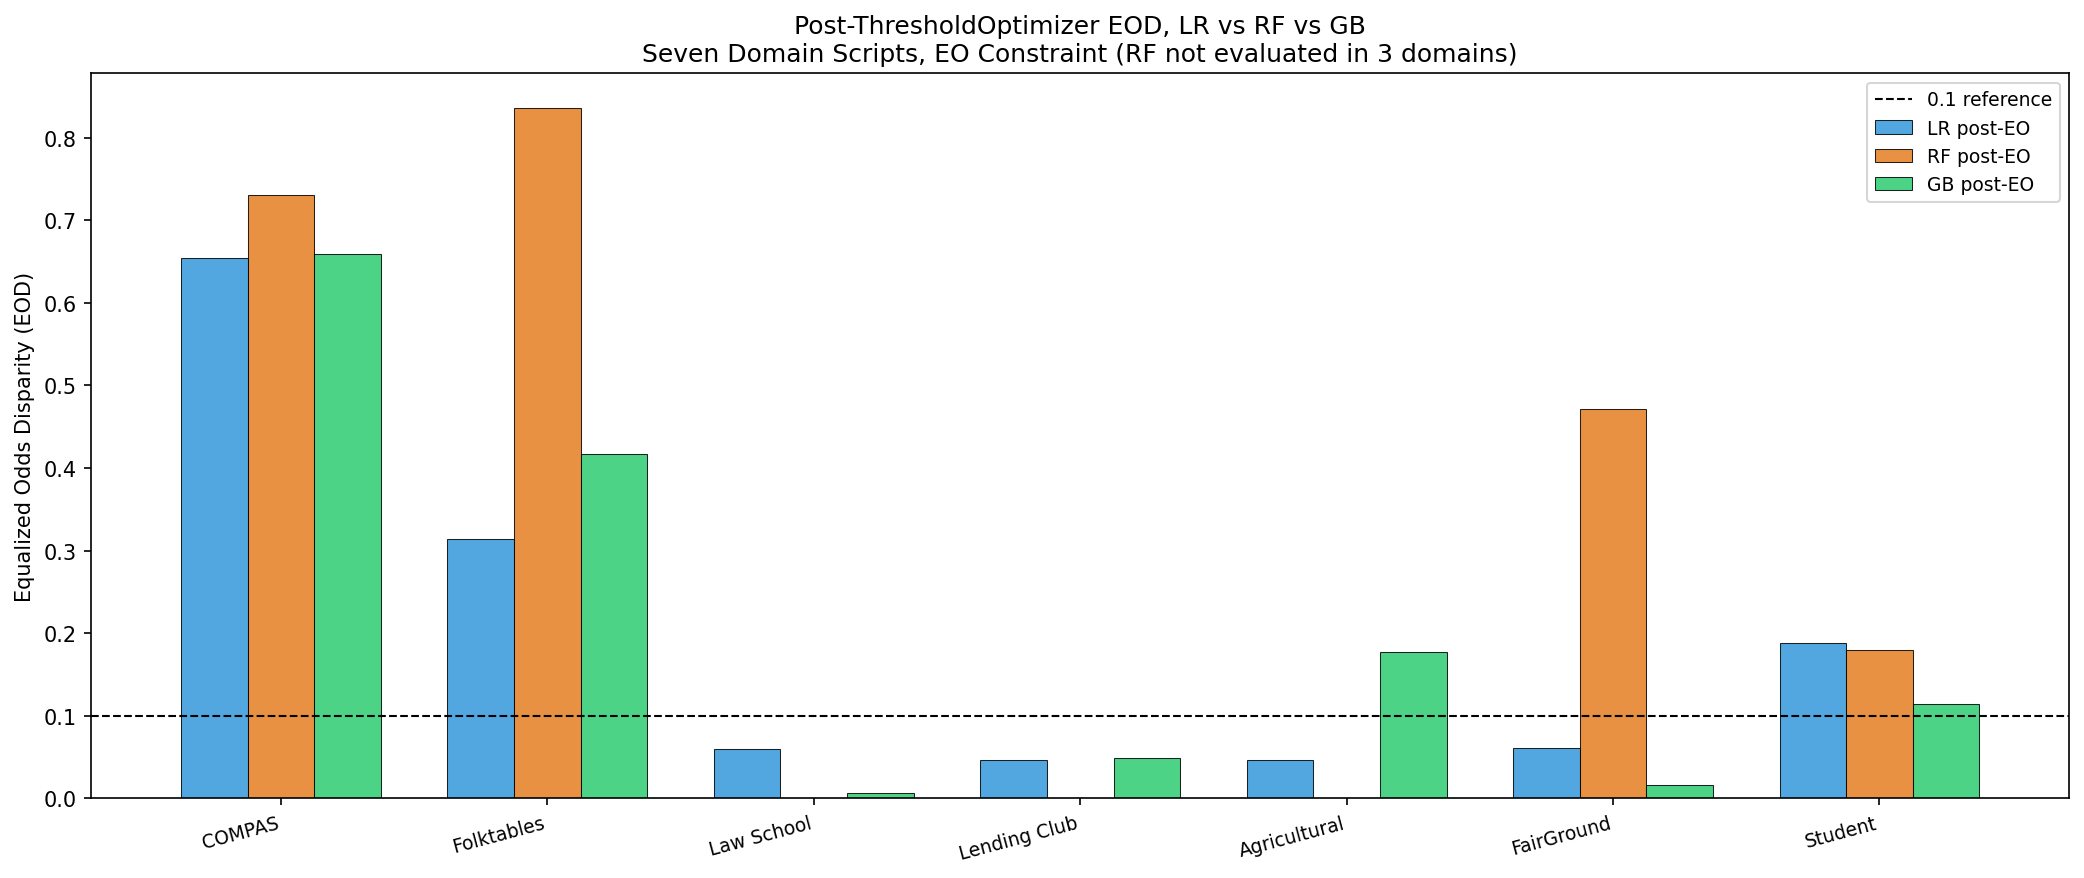

In [5]:
display(Image('figures/stage2/aggregation_post_eo_eod.png'))

## 4. Post-constraint DPD heatmap

The post-constraint DPD values as a model-by-domain grid, with models a domain did not evaluate left blank.

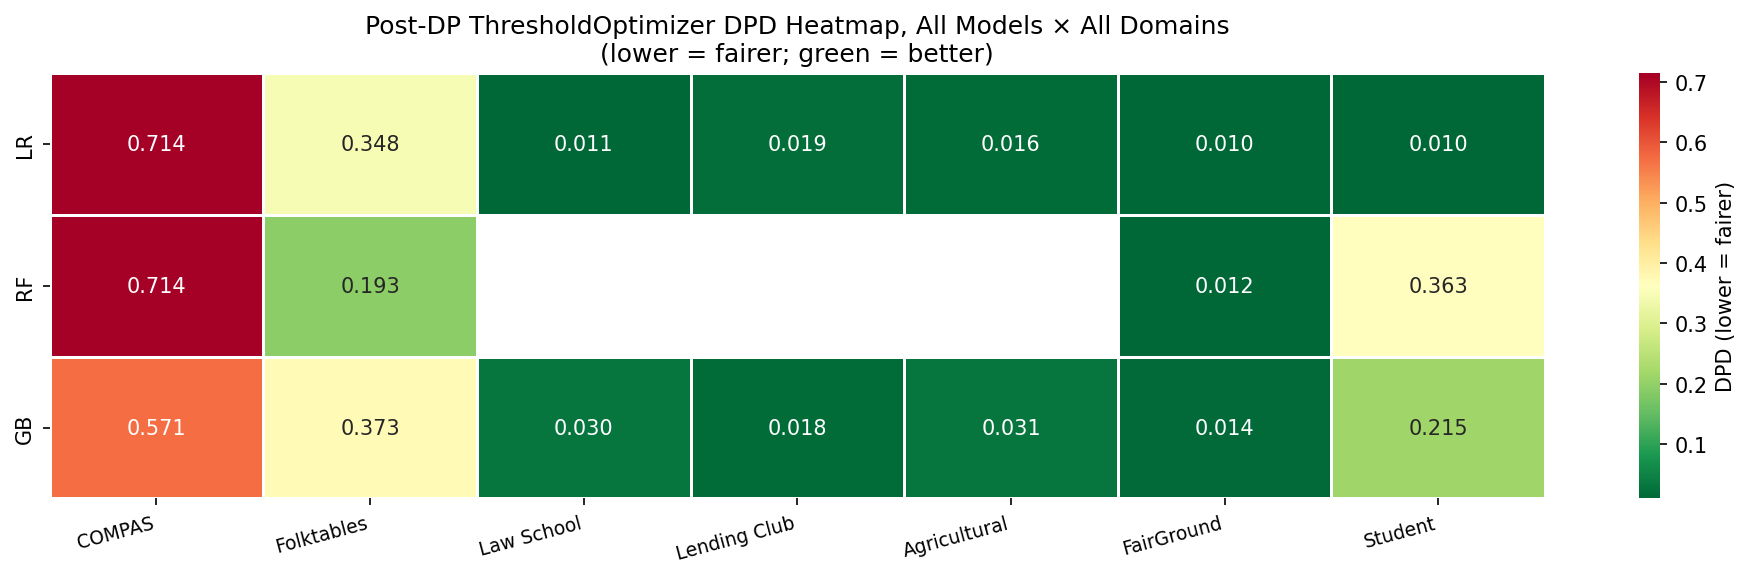

In [6]:
display(Image('figures/stage2/aggregation_dpd_heatmap.png'))

## 5. Post-constraint EOD heatmap

The post-constraint EOD values as a model-by-domain grid.

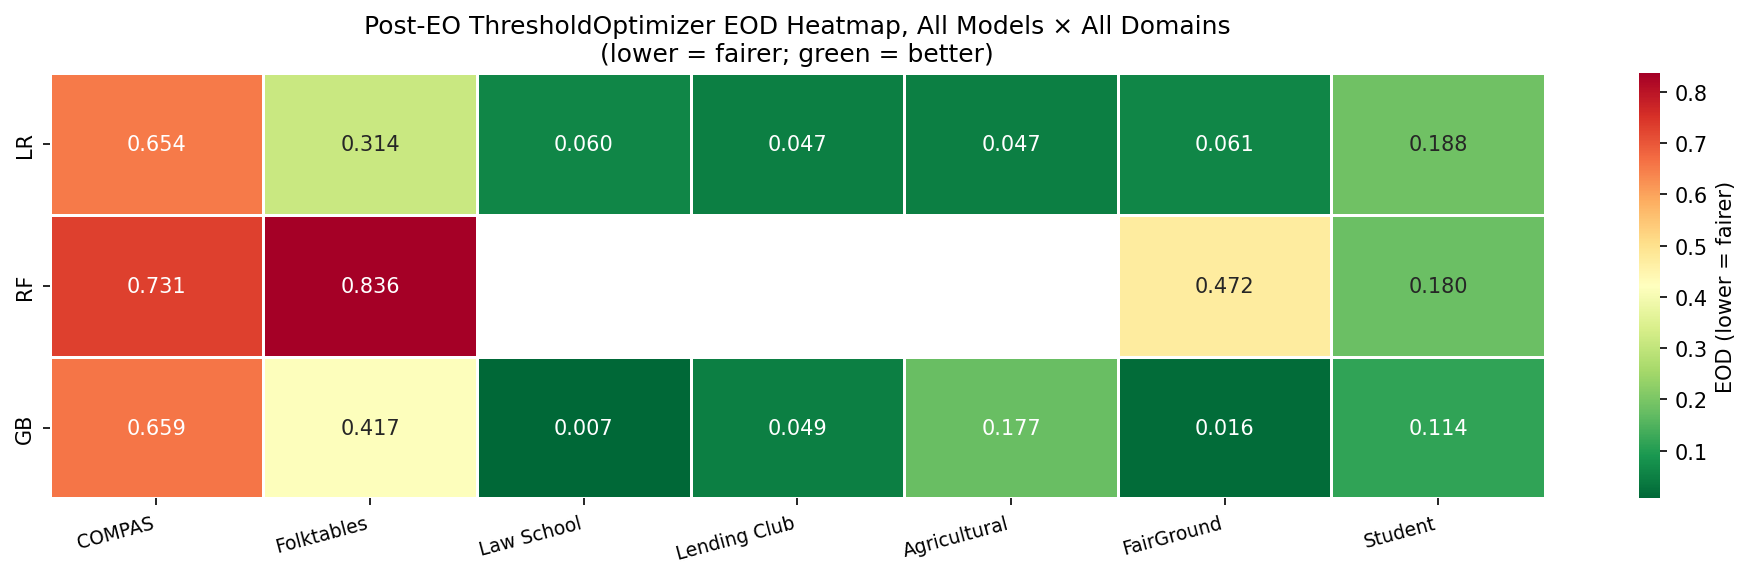

In [7]:
display(Image('figures/stage2/aggregation_eod_heatmap.png'))

## 6. Accuracy cost heatmap

Accuracy lost under the demographic parity constraint for each model and domain.

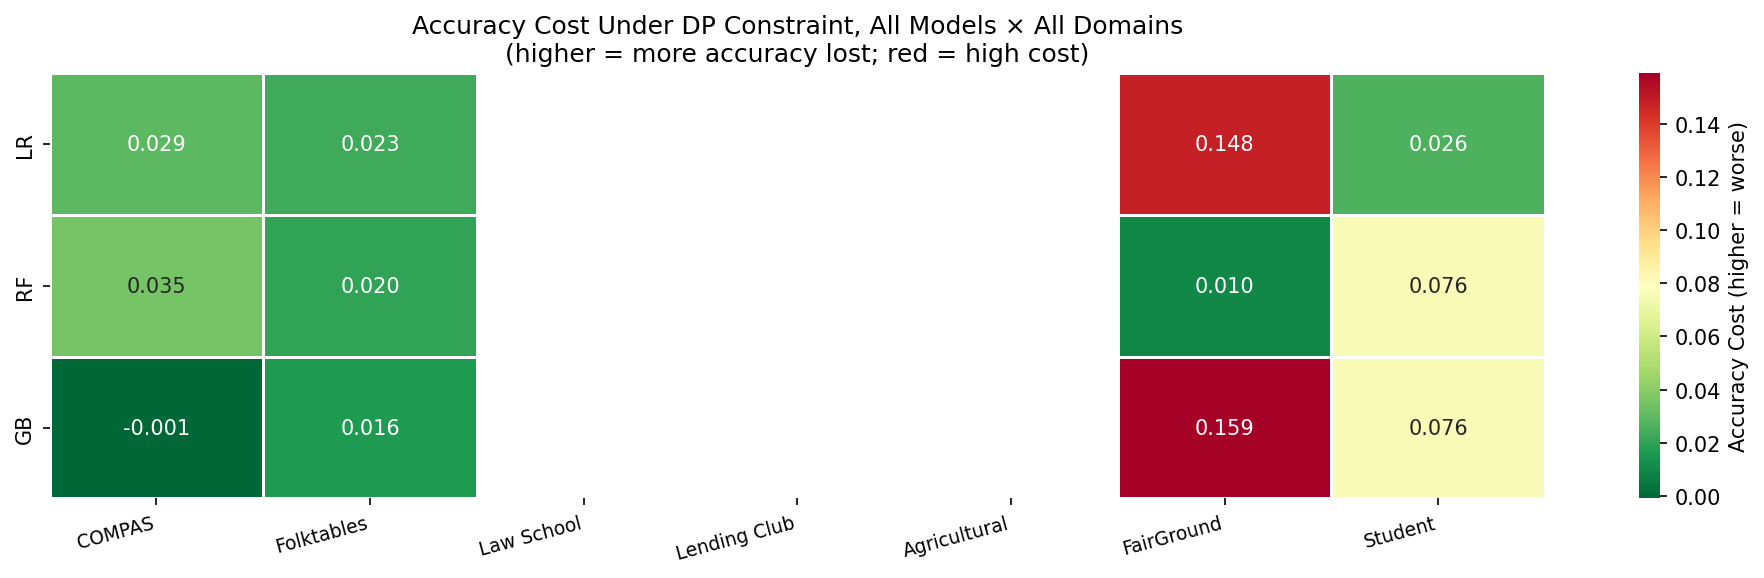

In [8]:
display(Image('figures/stage2/aggregation_acc_cost_heatmap.png'))

## 7. Effectiveness pattern

Baseline DPD against DPD after the demographic parity constraint for every evaluated model-domain pair, on log scales. Points below the diagonal improved. The shaded bands mark the pairs above 0.2 and below 0.05 that the paper counts, and the arrows move each pair that worsened to where the group-size check (COMPAS, Folktables) or held-out thresholds (Student, MEPS) place it.

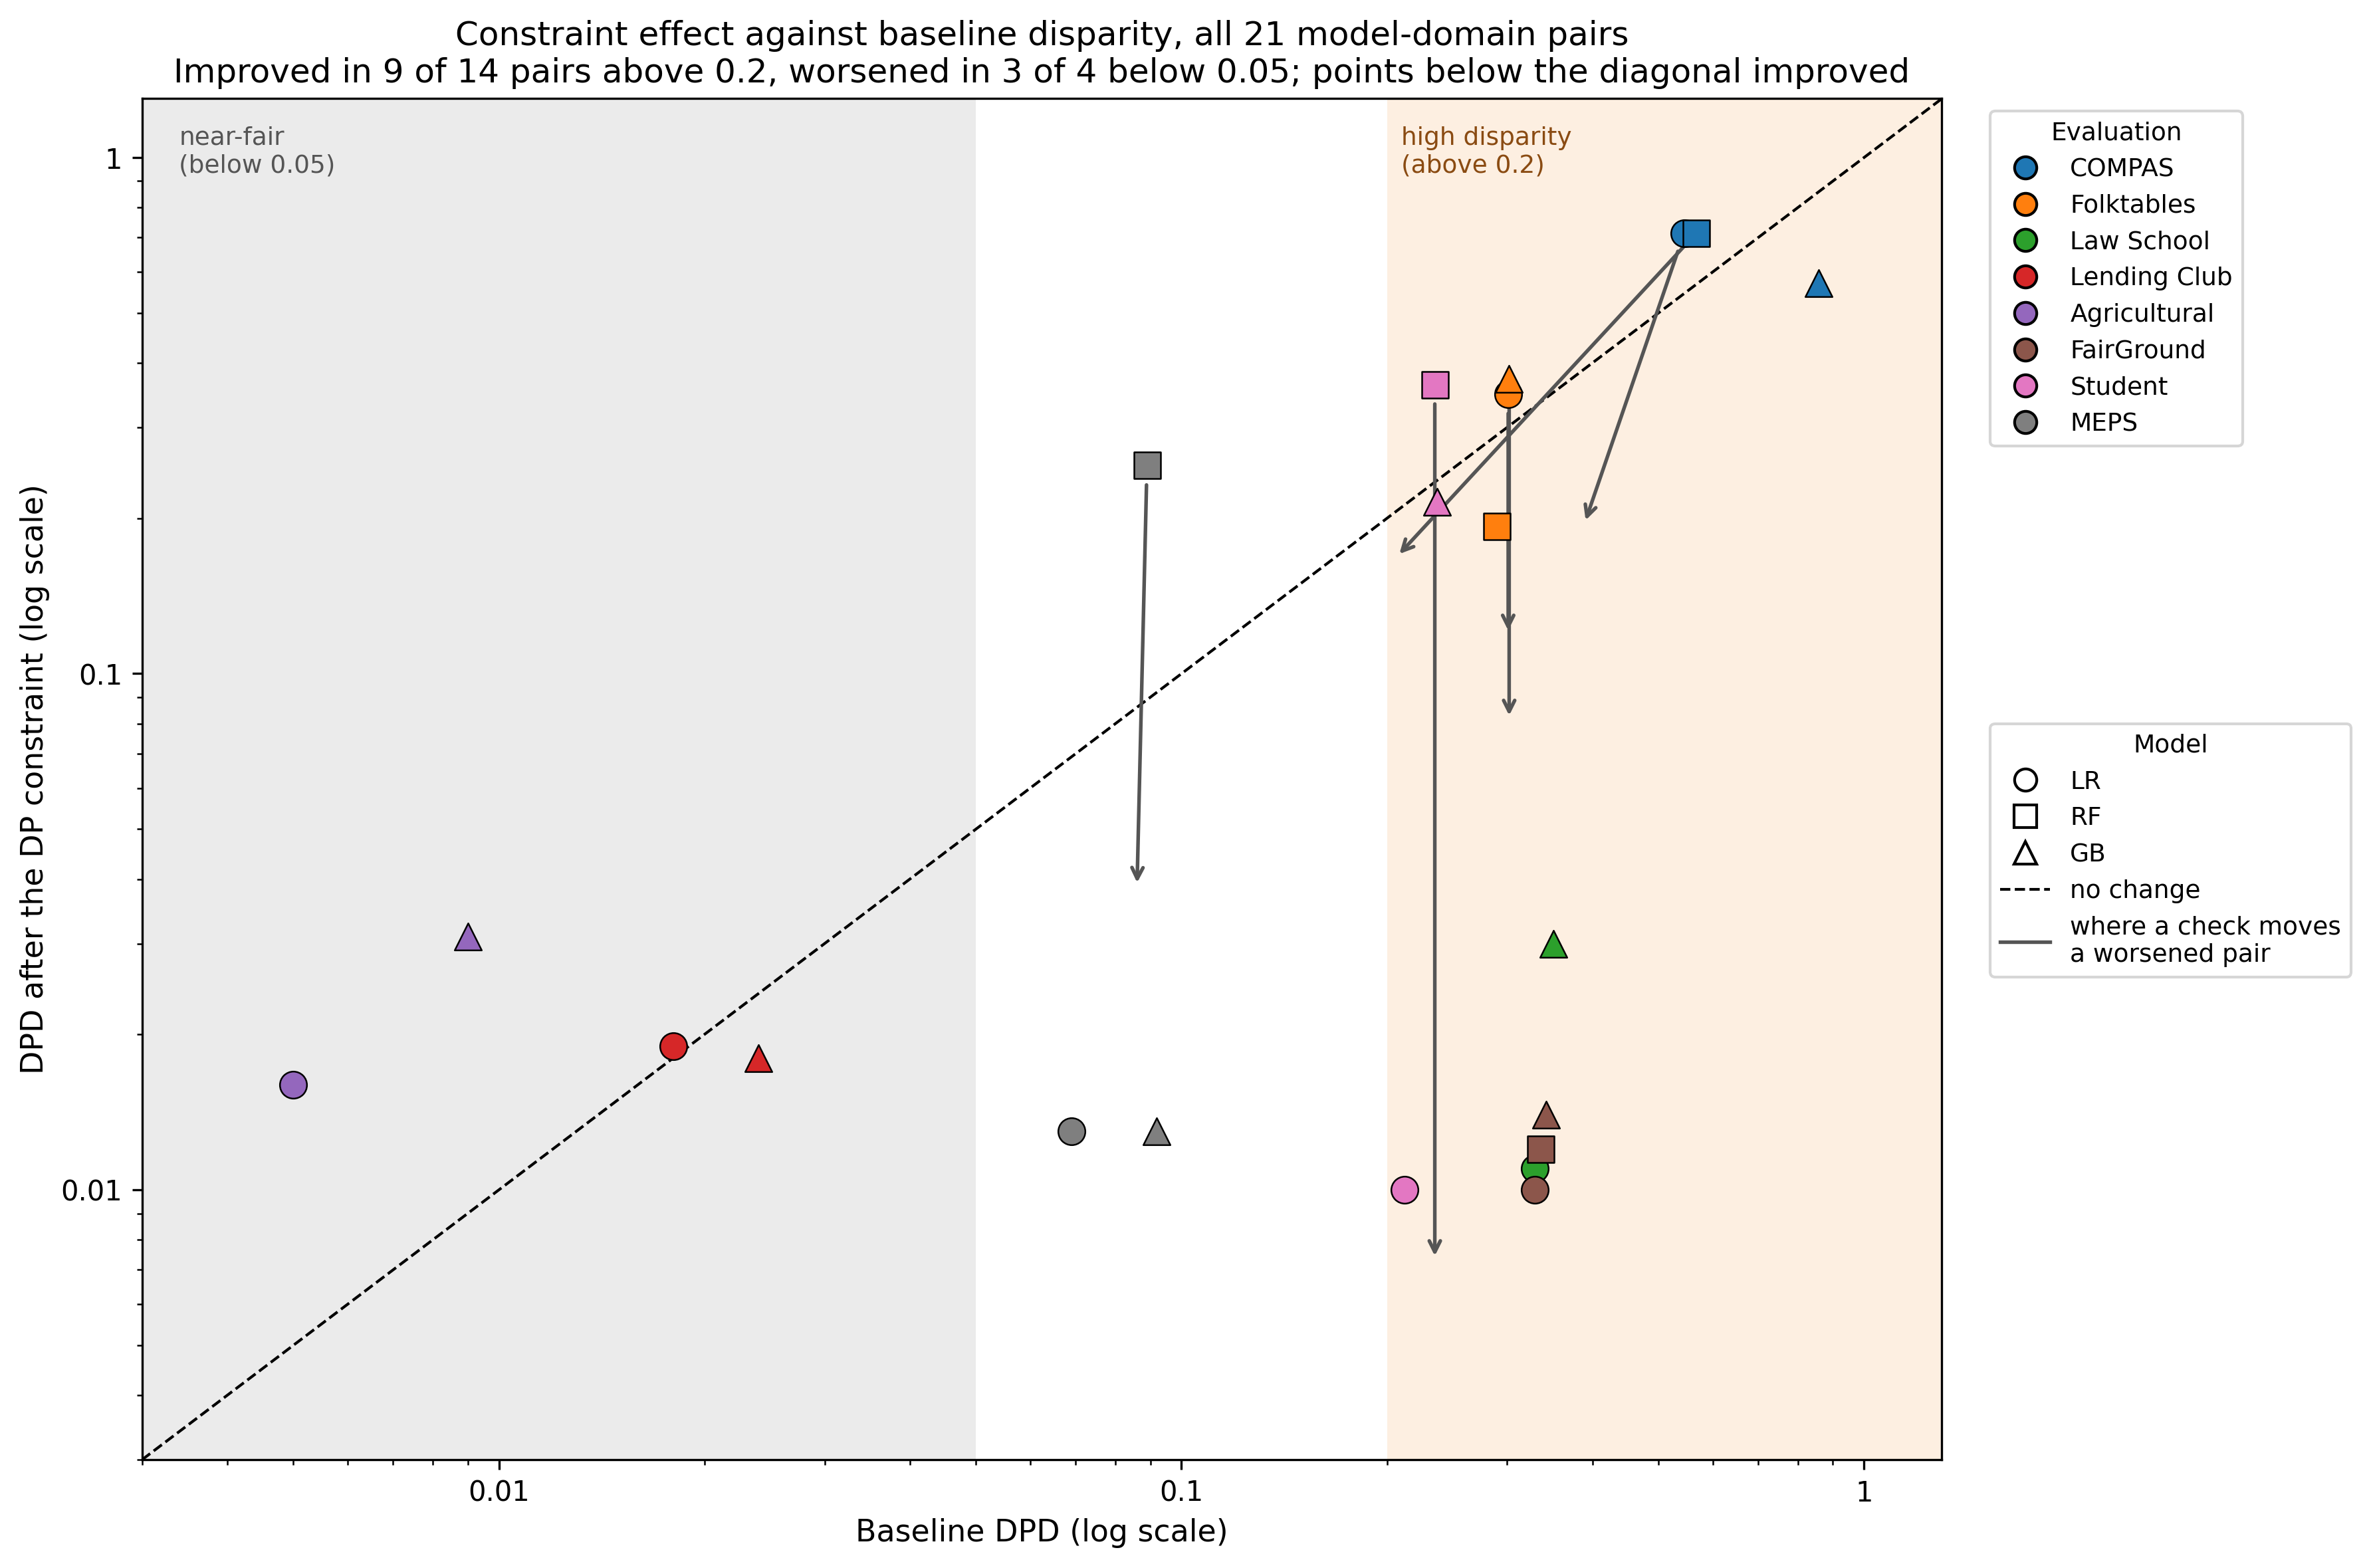

In [9]:
display(Image('figures/stage2/aggregation_effectiveness_pattern.png'))

## 8. What the two sensitivity checks change

Each model-domain pair is drawn twice: once as the intervention scripts run it, once under the check. The marker is the disparity before the constraint and the arrow head is the disparity after it, so a pair whose arrow flips from red to green between the two designs is one the paper reads as a product of the design it was measured under. The left panel drops groups with fewer than 30 test records (Section 6.2), the right chooses the thresholds on records the model did not train on (Section 6.4).

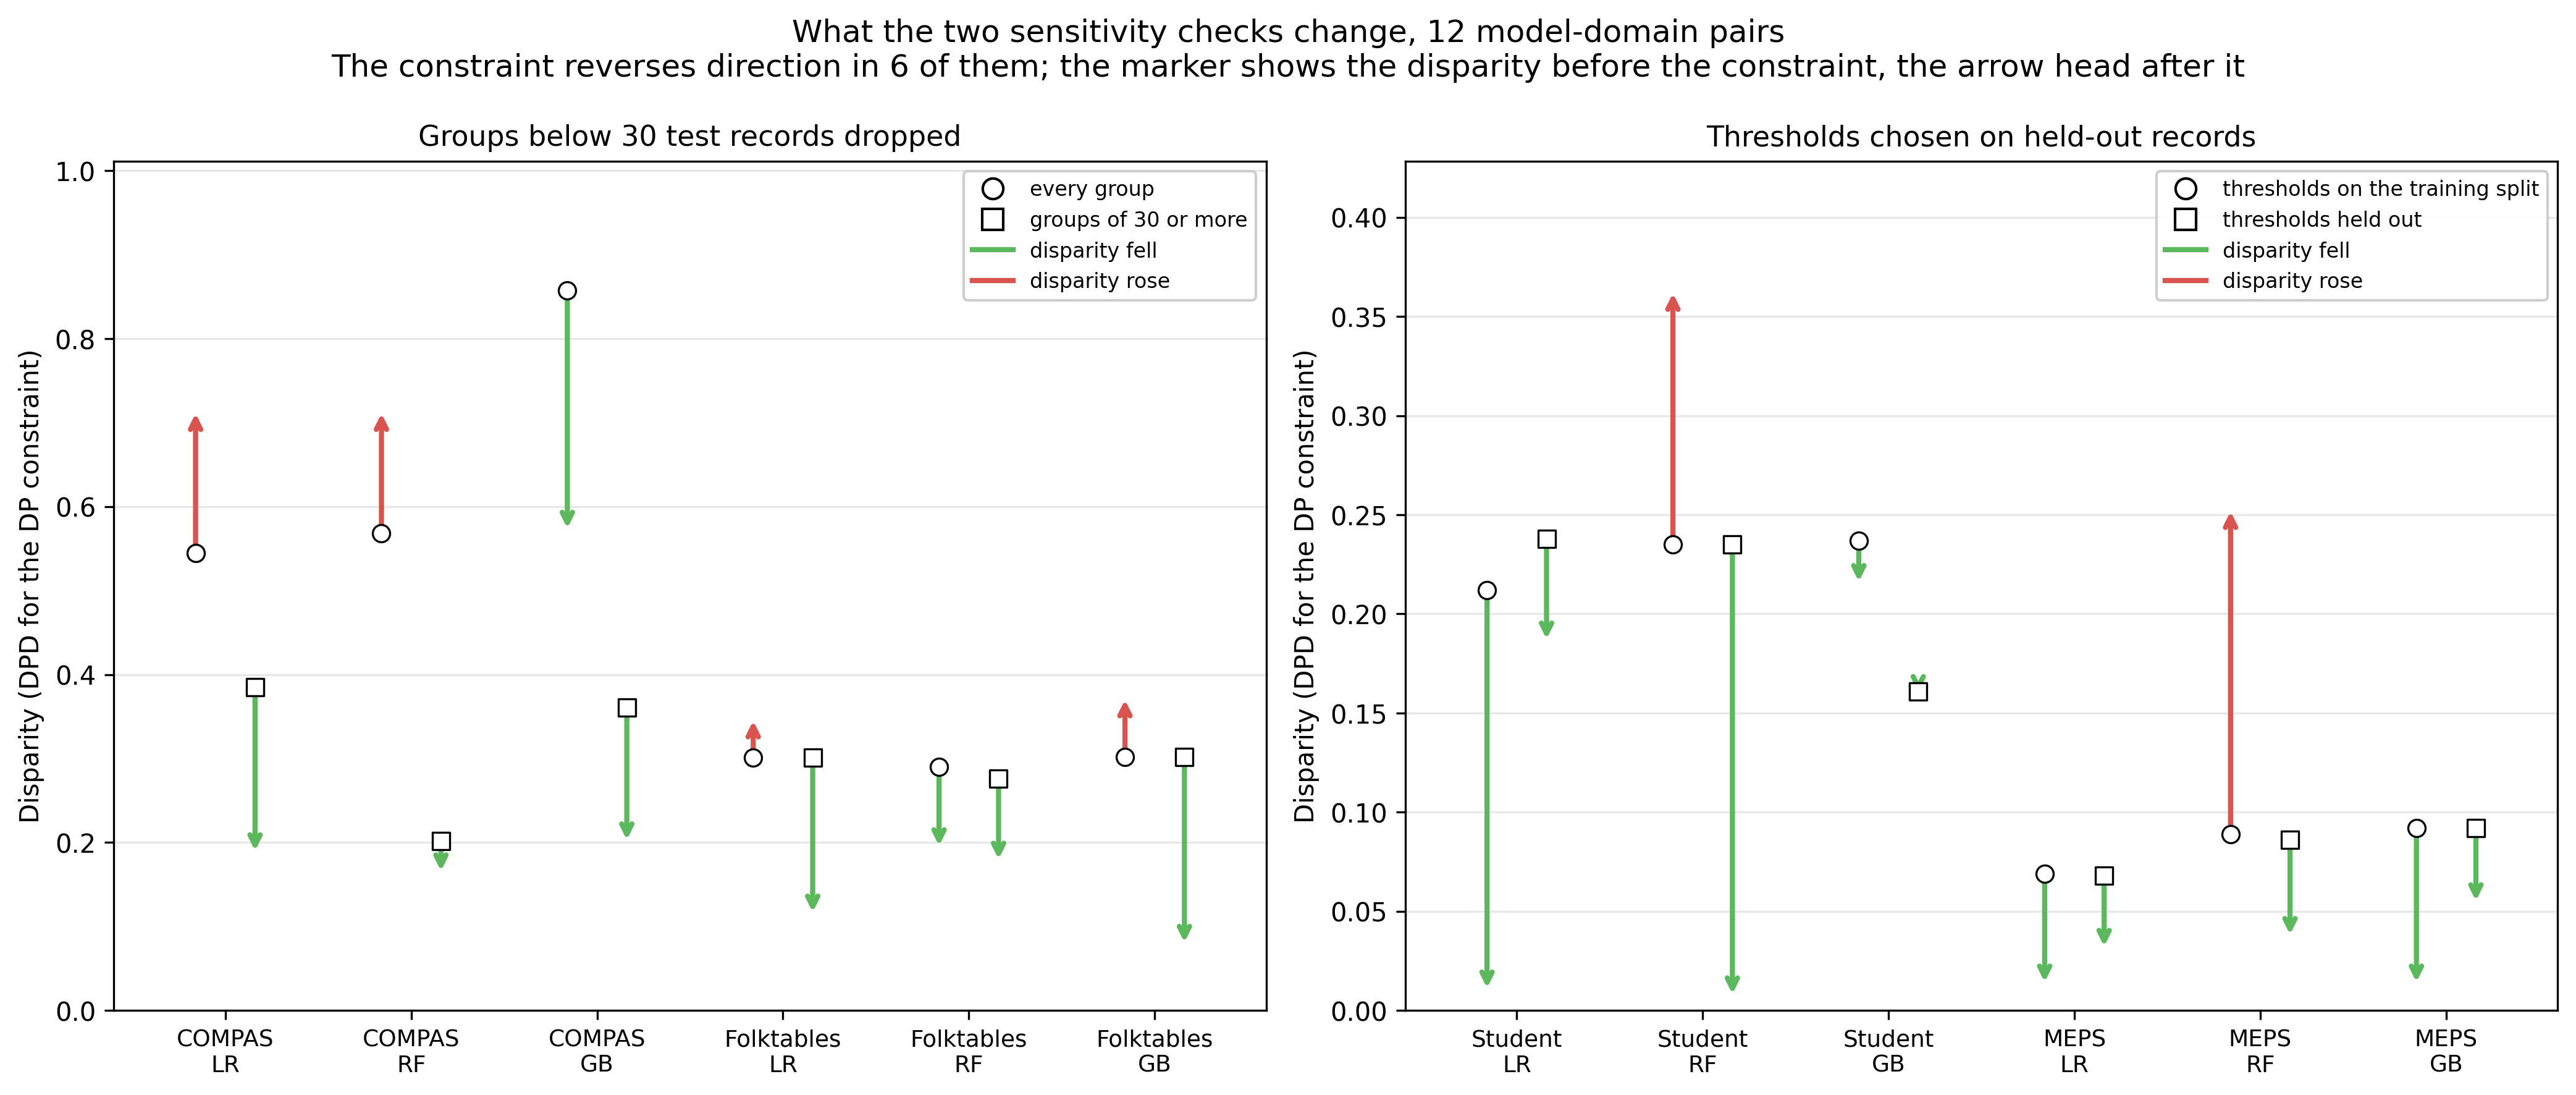

In [10]:
display(Image('figures/stage2/aggregation_check_designs.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.